# **Day 38: XGBoost, LightGBM and CatBoost**
*Module 6 - Ensemble Learning*

Three industrial-strength gradient-boosting libraries dominate tabular ML (Kaggle, industry, and increasingly remote sensing). All implement Day 37's ideas with engineering and regularisation improvements.

| Library | Key ideas | Strengths |
|---|---|---|
| **XGBoost** (Chen & Guestrin, 2016) | 2nd-order (Newton) boosting, explicit L1/L2 on leaf weights, sparsity-aware splits | Accurate, mature, GPU, widely cited |
| **LightGBM** (Ke et al., 2017) | Histogram splits, **leaf-wise** growth, GOSS sampling, EFB feature bundling | Very fast on large data |
| **CatBoost** (Prokhorenkova et al., 2018) | **Ordered boosting** and ordered target statistics for categoricals, symmetric trees | Best out-of-the-box with categoricals; robust defaults |

> XGBoost, LightGBM and CatBoost are fast, carefully engineered versions of gradient boosting. They handle large tables, missing values and (CatBoost) categorical features, and they win many tabular competitions.
>
> *Example:* LightGBM can train on millions of pixels with 100 features in minutes, which suits wall-to-wall mapping.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(38)
print("xgboost", xgb.__version__, "| lightgbm", lgb.__version__, "| catboost", cb.__version__)

xgboost 3.4.1 | lightgbm 4.7.0 | catboost 1.2.10


## **1. The XGBoost Objective**
At round $t$, XGBoost adds a tree $f_t$ minimising a second-order Taylor approximation of the loss plus a complexity penalty:
$$\mathcal{L}^{(t)} \approx \sum_i\Big[g_if_t(x_i) + \tfrac12 h_if_t(x_i)^2\Big] + \gamma T + \tfrac12\lambda\sum_{j=1}^T w_j^2$$
with gradients $g_i$, Hessians $h_i$, $T$ leaves with weights $w_j$. The optimal leaf weight and the **gain** of a split are closed-form:
$$w_j^* = -\frac{G_j}{H_j+\lambda},\qquad \text{Gain} = \frac12\left[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right]-\gamma$$
$\lambda$ (`reg_lambda`) shrinks leaf weights; $\gamma$ (`gamma` / `min_split_loss`) prunes splits with small gain.

In [2]:
# Verify the leaf-weight formula: one leaf, log-loss, starting from F = 0 (p = 0.5)
y_leaf = np.array([1, 1, 1, 0, 1, 0, 1, 1])
p = np.full(len(y_leaf), 0.5); G = np.sum(p - y_leaf); H = np.sum(p * (1 - p))
for lam in [0, 1, 10]:
    print(f"lambda = {lam:>2}: optimal leaf weight w* = {-G / (H + lam):.3f}  (log-odds of the leaf = {np.log(6 / 2):.3f})")

lambda =  0: optimal leaf weight w* = 1.000  (log-odds of the leaf = 1.099)
lambda =  1: optimal leaf weight w* = 0.667  (log-odds of the leaf = 1.099)
lambda = 10: optimal leaf weight w* = 0.167  (log-odds of the leaf = 1.099)


## **2. A Realistic Dataset**
Credit-default-style data with numeric, categorical (including high-cardinality) features and missing values.

In [3]:
n = 20000
df = pd.DataFrame({
    "income": rng.lognormal(10.5, 0.6, n), "age": rng.integers(21, 70, n), "debt_ratio": rng.beta(2, 5, n),
    "n_late_payments": rng.poisson(0.6, n), "months_employed": rng.exponential(60, n),
    "region": rng.choice([f"R{i}" for i in range(12)], n), "occupation": rng.choice([f"OCC{i:03d}" for i in range(150)], n),
    "loan_type": rng.choice(["home", "car", "personal", "education"], n, p=[0.3, 0.25, 0.35, 0.1])})
occ_risk = dict(zip([f"OCC{i:03d}" for i in range(150)], rng.normal(0, 0.6, 150)))
logit = (-2.0 - 0.5 * np.log(df.income / 36000) + 3.0 * df.debt_ratio + 0.6 * df.n_late_payments - 0.004 * df.months_employed
         + df.occupation.map(occ_risk) + df.loan_type.map({"home": -0.5, "car": 0.0, "personal": 0.4, "education": 0.2})
         + 0.8 * (df.debt_ratio > 0.5) * (df.n_late_payments > 1))
df["default"] = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
for c in ["income", "months_employed"]:
    df.loc[rng.random(n) < 0.07, c] = np.nan
cat_cols = ["region", "occupation", "loan_type"]
for c in cat_cols:
    df[c] = df[c].astype("category")
X, y = df.drop(columns="default"), df.default
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=0)
print("default rate:", y.mean().round(3), "| shapes:", X_fit.shape, X_val.shape, X_te.shape)

default rate: 0.316 | shapes: (13600, 8) (2400, 8) (4000, 8)


## **3. The Three Libraries (scikit-learn API, early stopping, native categoricals)**

In [4]:
results = {}

t = time.perf_counter()
xgb_m = xgb.XGBClassifier(n_estimators=3000, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.8,
                          reg_lambda=1.0, min_child_weight=5, tree_method="hist", enable_categorical=True,
                          eval_metric="logloss", early_stopping_rounds=100, random_state=0, n_jobs=-1)
xgb_m.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
results["XGBoost"] = (xgb_m.predict_proba(X_te)[:, 1], time.perf_counter() - t, xgb_m.best_iteration)

t = time.perf_counter()
lgb_m = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.03, num_leaves=31, subsample=0.8, subsample_freq=1,
                           colsample_bytree=0.8, reg_lambda=1.0, min_child_samples=20, random_state=0, n_jobs=-1, verbose=-1)
lgb_m.fit(X_fit, y_fit, eval_X=(X_val,), eval_y=(y_val,), callbacks=[lgb.early_stopping(100, verbose=False)])
results["LightGBM"] = (lgb_m.predict_proba(X_te)[:, 1], time.perf_counter() - t, lgb_m.best_iteration_)

t = time.perf_counter()
cb_m = cb.CatBoostClassifier(iterations=3000, learning_rate=0.05, depth=6, l2_leaf_reg=3, random_seed=0, verbose=0,
                             early_stopping_rounds=100, thread_count=-1, allow_writing_files=False)
cb_m.fit(X_fit.astype({c: str for c in cat_cols}), y_fit, cat_features=cat_cols, eval_set=(X_val.astype({c: str for c in cat_cols}), y_val))
results["CatBoost"] = (cb_m.predict_proba(X_te.astype({c: str for c in cat_cols}))[:, 1], time.perf_counter() - t, cb_m.get_best_iteration())

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
t = time.perf_counter()
hgb = HistGradientBoostingClassifier(max_iter=3000, learning_rate=0.03, categorical_features="from_dtype", early_stopping=True,
                                     validation_fraction=0.15, n_iter_no_change=100, random_state=0).fit(X_tr, y_tr)
results["sklearn HistGB"] = (hgb.predict_proba(X_te)[:, 1], time.perf_counter() - t, hgb.n_iter_)

from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
t = time.perf_counter()
rf = make_pipeline(make_column_transformer((OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols), remainder=SimpleImputer(strategy="median")),
                   RandomForestClassifier(500, min_samples_leaf=5, n_jobs=-1, random_state=0)).fit(X_tr, y_tr)
results["Random Forest (baseline)"] = (rf.predict_proba(X_te)[:, 1], time.perf_counter() - t, 500)

pd.DataFrame({k: {"ROC-AUC": roc_auc_score(y_te, p), "log loss": log_loss(y_te, p), "seconds": s, "trees used": it}
              for k, (p, s, it) in results.items()}).T.round(4)

,ROC-AUC,log loss,seconds,trees used
XGBoost,0.7467,0.5372,0.5125,99.0
LightGBM,0.7494,0.5354,0.2255,106.0
CatBoost,0.7498,0.5340,8.0601,149.0
sklearn HistGB,0.7285,0.5527,0.6039,213.0
Random Forest (baseline),0.6981,0.5688,1.2096,500.0


With good settings the three libraries perform similarly; differences are often smaller than the run-to-run noise. Choose by data size, categorical handling and convenience, and **compare honestly with CV and the same preprocessing**.

## **4. Validation Curves From the Boosting Log**

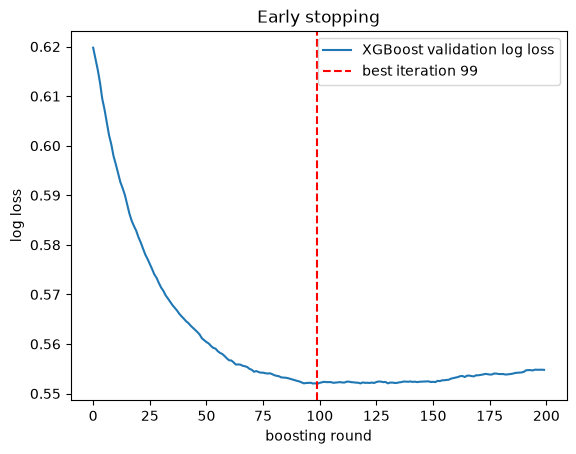

In [5]:
ev = xgb_m.evals_result()["validation_0"]["logloss"]
plt.plot(ev, label="XGBoost validation log loss"); plt.axvline(xgb_m.best_iteration, c="r", ls="--", label=f"best iteration {xgb_m.best_iteration}")
plt.xlabel("boosting round"); plt.ylabel("log loss"); plt.legend(); plt.title("Early stopping"); plt.show()

## **5. Feature Importance Types**

| Type | Meaning |
|---|---|
| `weight` / `split` | Number of times a feature is used to split |
| `gain` | Average (or total) loss reduction from its splits (most informative of the three) |
| `cover` | Average number of samples affected by its splits |

All are training-data, model-internal measures. For explanations use permutation importance or SHAP (Day 44-45).

In [6]:
booster = xgb_m.get_booster()
imp = pd.DataFrame({k: pd.Series(booster.get_score(importance_type=k)) for k in ["weight", "gain", "cover"]})
(imp / imp.sum()).round(3).sort_values("gain", ascending=False)

,weight,gain,cover
n_late_payments,0.059,0.237,0.236
occupation,0.370,0.188,0.109
debt_ratio,0.102,0.155,0.159
loan_type,0.058,0.154,0.171
income,0.123,0.090,0.102
months_employed,0.114,0.071,0.104
region,0.135,0.060,0.055
age,0.040,0.045,0.064


# **Part 2: Going Deeper**

### A practical tuning strategy for boosted trees
1. Fix a moderate learning rate (0.05-0.1); use early stopping to pick the number of trees.
2. Tune tree complexity: `max_depth` (3-10) / `num_leaves` (15-255), `min_child_weight` / `min_child_samples`.
3. Tune randomness: `subsample`, `colsample_bytree` (0.5-1.0).
4. Tune regularisation: `reg_lambda`, `reg_alpha`, `gamma`.
5. Lower the learning rate (0.01-0.03) and re-run early stopping for the final model.
Use Bayesian optimisation (Day 41) for steps 2-4.

### Custom objective: asymmetric loss
Sometimes under-predicting is worse than over-predicting (e.g. flood depth for evacuation). XGBoost accepts any loss via its gradient and Hessian.

In [7]:
def asymmetric_mse(alpha=4.0):
    def obj(y_true, y_pred):
        r = y_pred - y_true
        w = np.where(r < 0, alpha, 1.0)                 # under-prediction costs alpha times more
        return 2 * w * r, 2 * w                          # gradient, Hessian
    return obj

xr = rng.uniform(0, 10, (3000, 1)); yr = 2 * np.sin(xr.ravel()) + 3 + rng.normal(0, 1, 3000)
plain = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1).fit(xr, yr)
asym = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, objective=asymmetric_mse(4.0)).fit(xr, yr)
for name, m in [("squared error", plain), ("asymmetric (under x4)", asym)]:
    res_ = m.predict(xr) - yr
    print(f"{name:<22} share of under-predictions {np.mean(res_ < 0):.2f} | mean residual {res_.mean():+.3f}")

squared error          share of under-predictions 0.51 | mean residual -0.000
asymmetric (under x4)  share of under-predictions 0.30 | mean residual +0.519


### Cross-validated comparison with confidence
Single train/test splits can rank libraries differently from run to run. Compare with repeated CV and report mean +/- sd.

In [8]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
Xs = X.sample(8000, random_state=0); ys = y.loc[Xs.index]
cmp = {"XGBoost": xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, tree_method="hist", enable_categorical=True, n_jobs=-1, random_state=0),
       "LightGBM": lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, n_jobs=-1, random_state=0),
       "HistGB": HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, categorical_features="from_dtype", early_stopping=False, random_state=0)}
for name, m in cmp.items():
    s = cross_val_score(m, Xs, ys, cv=cv, scoring="roc_auc")
    print(f"{name:<9} ROC-AUC {s.mean():.4f} +/- {s.std():.4f}")

XGBoost   ROC-AUC 0.6962 +/- 0.0062


LightGBM  ROC-AUC 0.7191 +/- 0.0061


HistGB    ROC-AUC 0.7064 +/- 0.0091


Notice that the ranking changed compared with the tuned, early-stopped models above: with these **fixed** settings (400 trees, depth 5, no early stopping) XGBoost overfits this smaller 8,000-row sample. A library comparison is only fair if **each** model is tuned (or early-stopped) with the same budget. Otherwise we are comparing hyperparameter choices, not libraries.

## **Practice Problems**
1. Train LightGBM with `num_leaves=7, 31, 127` and plot the validation log loss curves. Which overfits fastest?
2. Remove `enable_categorical=True` from XGBoost and one-hot encode the categoricals instead. Compare AUC and training time.
3. Add a monotonic constraint (+1) on `debt_ratio` in LightGBM (`monotone_constraints`). Does AUC change?
4. *(Advanced)* Implement the XGBoost split gain formula and compute the gain of splitting `y_leaf` into its first 4 and last 4 samples for lambda = 1, gamma = 0.

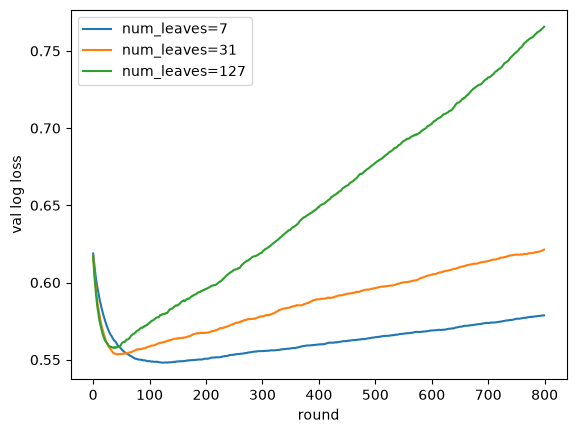

one-hot XGBoost: AUC 0.7186 (171 columns, 0.4s)
monotone LightGBM AUC 0.7366
gain: -0.1667 -> negative: the split does not pay for the regularisation, so XGBoost would not make it


In [9]:
# Solution 1
for nl in [7, 31, 127]:
    m = lgb.LGBMClassifier(n_estimators=800, learning_rate=0.05, num_leaves=nl, verbose=-1, random_state=0).fit(X_fit, y_fit, eval_X=(X_val,), eval_y=(y_val,))
    plt.plot(m.evals_result_["valid_0"]["binary_logloss"], label=f"num_leaves={nl}")
plt.legend(); plt.xlabel("round"); plt.ylabel("val log loss"); plt.show()
# Solution 2
X_oh = pd.get_dummies(X, columns=cat_cols, dtype=float)
Xo_tr, Xo_te = X_oh.loc[X_tr.index], X_oh.loc[X_te.index]
t = time.perf_counter()
m_oh = xgb.XGBClassifier(n_estimators=xgb_m.best_iteration + 1, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=0).fit(Xo_tr, y_tr)
print(f"one-hot XGBoost: AUC {roc_auc_score(y_te, m_oh.predict_proba(Xo_te)[:, 1]):.4f} ({X_oh.shape[1]} columns, {time.perf_counter() - t:.1f}s)")
# Solution 3
mono = [1 if c == "debt_ratio" else 0 for c in X.columns]
m_mono = lgb.LGBMClassifier(n_estimators=lgb_m.best_iteration_, learning_rate=0.03, monotone_constraints=mono, verbose=-1, random_state=0).fit(X_tr, y_tr)
print(f"monotone LightGBM AUC {roc_auc_score(y_te, m_mono.predict_proba(X_te)[:, 1]):.4f}")
# Solution 4
def xgb_gain(g, h, left, lam=1.0, gamma=0.0):
    GL, HL, GR, HR = g[left].sum(), h[left].sum(), g[~left].sum(), h[~left].sum()
    return 0.5 * (GL ** 2 / (HL + lam) + GR ** 2 / (HR + lam) - (GL + GR) ** 2 / (HL + HR + lam)) - gamma
gg, hh = p - y_leaf, p * (1 - p)
print("gain:", round(xgb_gain(gg, hh, np.arange(8) < 4), 4), "-> negative: the split does not pay for the regularisation, so XGBoost would not make it")

## **Key References**
- Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *KDD 2016*, 785-794.
- Ke, G. et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. *NeurIPS 30*.
- Prokhorenkova, L., Gusev, G., Vorobev, A., Dorogush, A. V., & Gulin, A. (2018). CatBoost: Unbiased boosting with categorical features. *NeurIPS 31*.
- Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on typical tabular data? *NeurIPS 35 Datasets and Benchmarks*.
- Shwartz-Ziv, R., & Armon, A. (2022). Tabular data: Deep learning is not all you need. *Information Fusion*, 81, 84-90.